In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

drive_path = "/content/drive/MyDrive/PROJECT_FSD50K"
local_path = "/content/fsd50k_local"

# Only extract the audio archives if they haven't been extracted already
dev_audio_dir = os.path.join(local_path, "FSD50K.dev_audio")

if os.path.exists(dev_audio_dir) and len(os.listdir(dev_audio_dir)) > 100:
    print(f"Dataset already extracted at {local_path}")
else:
    print("Extracting dataset archives")
    !unzip -q {drive_path}/FSD50K.metadata.zip -d {local_path}
    !unzip -q {drive_path}/FSD50K.ground_truth.zip -d {local_path}
    !7z x {drive_path}/FSD50K.eval_audio.zip -o{local_path} -y > /dev/null
    !7z x {drive_path}/FSD50K.dev_audio.zip -o{local_path} -y > /dev/null
    print("Extraction complete.")

Mounted at /content/drive
Extracting dataset archives
Extraction complete.


# **AST Fine-Tuning on FSD50K**

## **Purpose**

This notebook fine-tunes the Audio Spectrogram Transformer (AST) pretrained on AudioSet (Gong et al. 2021) on the FSD50K dataset. It is the main experimental model of the project, designed to test whether a Transformer-based architecture with global attention can outperform the convolutional baseline (notebook `04_cnn`) on multi-label sound event classification.

Key design decisions:

- **Base model**: `MIT/ast-finetuned-audioset-10-10-0.4593`, pretrained on AudioSet (the superset from which FSD50K was curated).
- **Vocabulary**: same 100-class vocabulary as the CNN, ensuring a fair comparison.
- **Regularization**: SpecAugment during training, matching the CNN setup.
- **Fine-tuning protocol**: AdamW with linear warmup + decay, and principled early stopping based on validation mAP.

The trained model and predictions are saved to Drive for use in the robustness evaluation.

## **Library Imports and Environment Setup**

This notebook fine-tunes the Audio Spectrogram Transformer (AST) on FSD50K. The model is loaded from the Hugging Face Hub (`MIT/ast-finetuned-audioset-10-10-0.4593`), the official checkpoint from Gong et al. 2021 pretrained on AudioSet. Since AudioSet is the superset from which FSD50K was curated, the backbone contains representations directly relevant to our task. We install `transformers` and import all required libraries, then set random seeds for reproducibility.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
from transformers import ASTForAudioClassification, ASTFeatureExtractor, get_linear_schedule_with_warmup
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)

Device: cuda


## **Dataset Paths and Ground Truth Loading**

We load the FSD50K ground truth files for both splits and parse the multi-label strings. The full path to each audio file is constructed for later access by the DataLoader.

In [ ]:
BASE_DIR   = "/content/fsd50k_local"
DEV_CSV    = os.path.join(BASE_DIR, "FSD50K.ground_truth", "dev.csv")
EVAL_CSV   = os.path.join(BASE_DIR, "FSD50K.ground_truth", "eval.csv")
DEV_AUDIO  = os.path.join(BASE_DIR, "FSD50K.dev_audio")
EVAL_AUDIO = os.path.join(BASE_DIR, "FSD50K.eval_audio")

dev_df  = pd.read_csv(DEV_CSV)
eval_df = pd.read_csv(EVAL_CSV)

dev_df["path"]  = dev_df["fname"].astype(str).apply(lambda x: os.path.join(DEV_AUDIO,  f"{x}.wav"))
eval_df["path"] = eval_df["fname"].astype(str).apply(lambda x: os.path.join(EVAL_AUDIO, f"{x}.wav"))

dev_df["label_list"]  = dev_df["labels"].astype(str).str.split(",")
eval_df["label_list"] = eval_df["labels"].astype(str).str.split(",")

print(f"Dev samples: {len(dev_df)}  |  Eval samples: {len(eval_df)}")

Dev samples: 40966  |  Eval samples: 10231


## **Class Selection: Loading Vocabulary from Notebook 03**

The label space is defined by the redundancy analysis in `03_label_correlation_analysis`. We load the configuration from Drive to ensure the AST uses exactly the same 100 classes as the CNN, making the comparison fair. Samples without any valid label after filtering are discarded.

In [ ]:
# Load vocabulary configuration produced by the label redundancy analysis
config_path = "/content/drive/MyDrive/PROJECT_FSD50K/label_config.json"
if not os.path.exists(config_path):
    raise FileNotFoundError(
        f"Configuration file not found at {config_path}. "
        "Run 03_label_redundancy_analysis first."
    )

with open(config_path) as f:
    cfg = json.load(f)

DROP_LABELS = set(cfg["drop_labels"])
VOCAB_SIZE  = cfg["vocabulary_size"]
print(f"Dropped labels: {sorted(DROP_LABELS)}")
print(f"Vocabulary size: {VOCAB_SIZE}")

# Count label frequencies and build the final vocabulary
all_labels   = [lab for labs in dev_df["label_list"] for lab in labs]
label_counts = Counter(all_labels)

# Drop redundant labels first, then take top-N by frequency
top_labels = [l for l, _ in label_counts.most_common() if l not in DROP_LABELS][:VOCAB_SIZE]
print(f"Final number of classes: {len(top_labels)}")

# Filter samples to keep only labels in the final vocabulary
def filter_labels(lst):
    return [l for l in lst if l in top_labels]

dev_df["label_filt"]  = dev_df["label_list"].apply(filter_labels)
eval_df["label_filt"] = eval_df["label_list"].apply(filter_labels)

dev_df  = dev_df[dev_df["label_filt"].apply(len) > 0].reset_index(drop=True)
eval_df = eval_df[eval_df["label_filt"].apply(len) > 0].reset_index(drop=True)

train_df = dev_df[dev_df["split"] == "train"].reset_index(drop=True)
val_df   = dev_df[dev_df["split"] == "val"].reset_index(drop=True)
test_df  = eval_df.reset_index(drop=True)

mlb = MultiLabelBinarizer(classes=top_labels)
mlb.fit([top_labels])
NUM_CLASSES = len(top_labels)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Dropped labels: ['Musical_instrument', 'Plucked_string_instrument', 'Thunderstorm']
Vocabulary size: 100
Final number of classes: 100

Train: 35685  |  Val: 4006  |  Test: 9878


## **Loading the Pretrained AST Model**

We load the pretrained AST from Hugging Face (`MIT/ast-finetuned-audioset-10-10-0.4593`), the official checkpoint from Gong et al. 2021. The `ASTFeatureExtractor` handles waveform-to-spectrogram conversion with AudioSet normalization statistics. The classification head is replaced (from 527 AudioSet classes to 100 FSD50K classes) via `ignore_mismatched_sizes=True`; this triggers an expected warning about uninitialized classifier weights, which is correct behavior. The rest of the ~86M parameters are preserved.

Setting `problem_type="multi_label_classification"` configures the model to use sigmoid activations and `BCEWithLogitsLoss` internally, matching the CNN setup.

In [ ]:
MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

# Feature extractor: waveform -> 128-bin log-Mel spectrogram (AudioSet norm)
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_NAME)
SR      = feature_extractor.sampling_rate
MAX_LEN = feature_extractor.max_length
print(f"Sampling rate: {SR} Hz | max_length: {MAX_LEN} frames | "
      f"mel bins: {feature_extractor.num_mel_bins}")

# Load pretrained model with a fresh classification head of NUM_CLASSES outputs
ast_model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
    problem_type="multi_label_classification",
).to(device)

n_params = sum(p.numel() for p in ast_model.parameters() if p.requires_grad)
print(f"AST trainable parameters: {n_params/1e6:.2f} M")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Sampling rate: 16000 Hz | max_length: 1024 frames | mel bins: 128


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AST trainable parameters: 86.27 M


## **Custom PyTorch Dataset for AST**

The dataset loads audio, applies the AST feature extractor (which outputs a normalized 128-bin spectrogram), and returns multi-label targets. Two optional arguments are included: `specaug` enables SpecAugment during training as a regularization technique (F=24 frequency bins, T=40 time frames, one mask of each type per clip), and `noise_snr_db` supports Gaussian noise injection at the waveform level. SpecAugment is enabled during training in this notebook; noise injection is reserved for the robustness experiments in `06_robutness`.

In [ ]:
DURATION  = 10
N_SAMPLES = SR * DURATION

def load_waveform_np(path):
    """Load and standardize an audio file (mono, 16 kHz, 10 s fixed length)."""
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SR:
        wav = torchaudio.functional.resample(wav, sr, SR)
    wav = wav.squeeze(0)
    if wav.shape[0] > N_SAMPLES:
        wav = wav[:N_SAMPLES]
    else:
        wav = F.pad(wav, (0, N_SAMPLES - wav.shape[0]))
    return wav.numpy()

class FSD50KASTDataset(Dataset):
    def __init__(self, df, mlb, specaug=False, noise_snr_db=None):
        self.df        = df.reset_index(drop=True)
        self.mlb       = mlb
        self.specaug   = specaug
        self.noise_snr = noise_snr_db

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            wav = load_waveform_np(row["path"])
        except Exception:
            wav = np.zeros(N_SAMPLES, dtype=np.float32)

        # Optional Gaussian noise at waveform level (robustness experiments)
        if self.noise_snr is not None:
            sig_p   = np.mean(wav**2) + 1e-10
            noise_p = sig_p / (10 ** (self.noise_snr / 10))
            wav     = wav + np.random.normal(0, np.sqrt(noise_p), wav.shape).astype(np.float32)

        # AST feature extractor: returns (time, mel_bins) normalized tensor
        feats = feature_extractor(wav, sampling_rate=SR, return_tensors="pt")
        x = feats["input_values"].squeeze(0)

        # SpecAugment (only enabled in later experiments)
        if self.specaug:
            t_mask, f_mask = 40, 24
            t0 = np.random.randint(0, max(1, x.shape[0] - t_mask))
            x[t0:t0 + t_mask, :] = 0
            f0 = np.random.randint(0, max(1, x.shape[1] - f_mask))
            x[:, f0:f0 + f_mask] = 0

        y = self.mlb.transform([row["label_filt"]])[0].astype(np.float32)
        return x, torch.from_numpy(y)

## **DataLoader Construction**

Batch size is set to 8 with gradient accumulation of 2, yielding an effective batch of 16. This is the standard compromise for fine-tuning large Transformers on a single A100 GPU: it fits in memory while keeping the effective batch large enough for stable gradient estimates.

In [ ]:
BATCH = 8
GRAD_ACCUM_STEPS = 2   # effective batch = 8 * 2 = 16

train_ds     = FSD50KASTDataset(train_df, mlb, specaug=True)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)

val_ds     = FSD50KASTDataset(val_df, mlb, specaug=False)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)

test_ds     = FSD50KASTDataset(test_df, mlb, specaug=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Batches per epoch: train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

Batches per epoch: train=4461  val=501  test=1235


## **Optimizer, Scheduler and Loss Function**

Following Gong et al. 2021 (original AST paper) and standard practice in Transformer fine-tuning:

- **Optimizer: AdamW with `lr=3e-5` and `weight_decay=5e-7`.** The LR is intermediate between the paper's AudioSet value (1e-5, for 2M samples) and the small-dataset value (2.5e-4), appropriate for our 37k-sample dataset. Weight decay of 5e-7 is the exact value from the paper.
- **Scheduler: linear warmup (10% of steps) + linear decay.** Standard in Transformer fine-tuning to protect pretrained representations from destructive gradient updates at the start of training. During warmup, the LR ramps up linearly from 0 to the target; after warmup, it decays linearly to 0.
- **Gradient clipping at 1.0.** Standard safeguard against occasional gradient spikes in Transformer training.
- **Loss: `BCEWithLogitsLoss`.** Same as CNN for multi-label classification and fair comparison.

Note that `get_linear_schedule_with_warmup` requires committing to a total number of training steps. We set it assuming the maximum number of epochs (20). If early stopping triggers earlier, the LR decay simply will not complete — this is acceptable and does not affect correctness.

In [ ]:
# Training hyperparameters
LR             = 3e-5
WEIGHT_DECAY   = 5e-7       # from Gong et al. 2021
MAX_EPOCHS     = 20
WARMUP_RATIO   = 0.10       # 10% of total steps
GRAD_CLIP      = 1.0

# Compute total training steps for the scheduler
steps_per_epoch = len(train_loader) // GRAD_ACCUM_STEPS
total_steps     = steps_per_epoch * MAX_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)
print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

# AdamW optimizer with weight decay from the AST paper
optim_ = torch.optim.AdamW(ast_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Linear warmup + linear decay scheduler (standard in Transformer fine-tuning)
sched = get_linear_schedule_with_warmup(
    optim_,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

criterion = nn.BCEWithLogitsLoss()

Total steps: 44600 | Warmup steps: 4460


## **Training and Evaluation Loop Utilities**

`ast_epoch` performs a full pass over a DataLoader. For training passes, it applies gradient accumulation (scaling the loss by the accumulation factor) and calls `scheduler.step()` once per effective batch. The `metrics` function is identical to the one in the CNN notebook for fair comparison.

In [ ]:
def ast_epoch(loader, train=True):
    ast_model.train(train)
    losses, all_y, all_p = [], [], []
    pbar = tqdm(loader, leave=False)

    for step, (x, y) in enumerate(pbar):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            out    = ast_model(input_values=x)
            logits = out.logits
            loss   = criterion(logits, y)

            if train:
                # Scale loss by accumulation steps (average across accumulated batches)
                loss_scaled = loss / GRAD_ACCUM_STEPS
                loss_scaled.backward()

                # Step the optimizer only every GRAD_ACCUM_STEPS micro-batches
                if (step + 1) % GRAD_ACCUM_STEPS == 0:
                    torch.nn.utils.clip_grad_norm_(ast_model.parameters(), GRAD_CLIP)
                    optim_.step()
                    sched.step()
                    optim_.zero_grad()

        losses.append(loss.item())
        all_y.append(y.detach().cpu().numpy())
        all_p.append(torch.sigmoid(logits).detach().cpu().numpy())
        pbar.set_postfix(loss=np.mean(losses))

    return np.mean(losses), np.concatenate(all_y), np.concatenate(all_p)


def metrics(y_true, y_prob, th=0.3):
    y_pred = (y_prob >= th).astype(int)
    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mAP":      average_precision_score(y_true, y_prob, average="macro"),
    }

## **AST Fine-Tuning with Principled Early Stopping**

The training loop uses the same early stopping criterion as the CNN for consistency: `PATIENCE=5`, `MIN_DELTA=0.001`. Two important considerations specific to Transformer fine-tuning:

- **During warmup (approximately the first 10% of training, ≈2 epochs), the LR is low and increasing.** Validation mAP may be unstable during this phase. We do not count these epochs toward the early stopping patience, to avoid premature halting before the model has had a chance to benefit from a non-zero learning rate.

The best checkpoint on validation mAP is retained throughout and restored before test evaluation.

In [ ]:
PATIENCE   = 5
MIN_DELTA  = 0.001
WARMUP_EPOCHS_IGNORE = 2   # do not count warmup epochs toward patience

best_map         = 0.0
best_state       = None
patience_counter = 0
stopped_at       = None

history = {"train_loss": [], "val_loss": [], "val_map": [],
           "val_microF1": [], "lr": []}

for ep in range(1, MAX_EPOCHS + 1):
    tr_loss, _, _          = ast_epoch(train_loader, train=True)
    val_loss, y_val, p_val = ast_epoch(val_loader,   train=False)
    m = metrics(y_val, p_val, th=0.3)
    current_lr = optim_.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_map"].append(m["mAP"])
    history["val_microF1"].append(m["micro_f1"])
    history["lr"].append(current_lr)

    # Check meaningful improvement
    improved = m["mAP"] > (best_map + MIN_DELTA)
    if improved:
        best_map   = m["mAP"]
        best_state = {k: v.cpu().clone() for k, v in ast_model.state_dict().items()}
        patience_counter = 0
        tag = "NEW BEST"
    else:
        # Do not count warmup epochs toward patience
        if ep > WARMUP_EPOCHS_IGNORE:
            patience_counter += 1
            tag = f"no improvement ({patience_counter}/{PATIENCE})"
        else:
            tag = "warmup, patience frozen"

    print(f"[Ep {ep:02d}] train={tr_loss:.4f}  val={val_loss:.4f}  "
          f"microF1={m['micro_f1']:.4f}  macroF1={m['macro_f1']:.4f}  "
          f"mAP={m['mAP']:.4f}  lr={current_lr:.1e}  [{tag}]")

    if patience_counter >= PATIENCE:
        stopped_at = ep
        print(f"\nEarly stopping triggered at epoch {ep}: "
              f"no val_mAP improvement >= {MIN_DELTA} in {PATIENCE} epochs.")
        break

ast_model.load_state_dict(best_state)
total_epochs = stopped_at if stopped_at else MAX_EPOCHS
print(f"\nTraining finished. Total epochs: {total_epochs}. Best val mAP: {best_map:.4f}")

# Save weights for use in 06_robustness
torch.save(ast_model.state_dict(),
           "/content/drive/MyDrive/PROJECT_FSD50K/ast.pt")

[Ep 01] train=0.1452  val=0.0593  microF1=0.5810  macroF1=0.3097  mAP=0.5639  lr=1.5e-05  [NEW BEST]


[Ep 02] train=0.0323  val=0.0442  microF1=0.6830  macroF1=0.5838  mAP=0.6748  lr=3.0e-05  [NEW BEST]


[Ep 03] train=0.0215  val=0.0425  microF1=0.7049  macroF1=0.6152  mAP=0.6897  lr=2.8e-05  [NEW BEST]


[Ep 04] train=0.0162  val=0.0417  microF1=0.7153  macroF1=0.6312  mAP=0.7005  lr=2.7e-05  [NEW BEST]


[Ep 05] train=0.0127  val=0.0432  microF1=0.7137  macroF1=0.6283  mAP=0.7000  lr=2.5e-05  [no improvement (1/5)]


...

[Ep 10] train=0.0046  val=0.0478  microF1=0.7343  macroF1=0.6486  mAP=0.7019  lr=1.7e-05  [no improvement (1/5)]


[Ep 11] train=0.0035  val=0.0509  microF1=0.7217  macroF1=0.6366  mAP=0.6966  lr=1.5e-05  [no improvement (2/5)]


[Ep 12] train=0.0029  val=0.0534  microF1=0.7146  macroF1=0.6301  mAP=0.6842  lr=1.3e-05  [no improvement (3/5)]


[Ep 13] train=0.0023  val=0.0557  microF1=0.7181  macroF1=0.6295  mAP=0.6845  lr=1.2e-05  [no improvement (4/5)]


[Ep 14] train=0.0020  val=0.0546  microF1=0.7255  macroF1=0.6450  mAP=0.6947  lr=1.0e-05  [no improvement (5/5)]

Early stopping triggered at epoch 14: no val_mAP improvement >= 0.001 in 5 epochs.

Training finished. Total epochs: 14. Best val mAP: 0.7016


## **Training Curves**

Three diagnostics: loss curves, validation metrics, and the learning rate schedule. The LR plot clearly shows the linear warmup phase followed by linear decay, which is the signature of the scheduler used for Transformer fine-tuning.

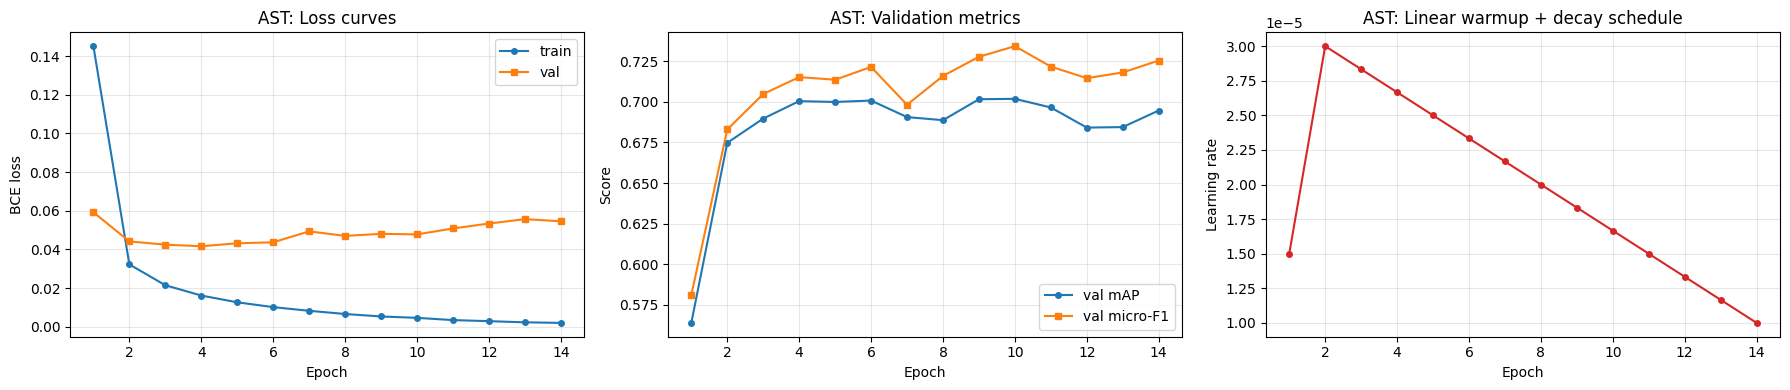

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs_axis = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_axis, history["train_loss"], label="train", marker="o", markersize=4)
axes[0].plot(epochs_axis, history["val_loss"],   label="val",   marker="s", markersize=4)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("AST: Loss curves"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(epochs_axis, history["val_map"],     label="val mAP",      marker="o", markersize=4)
axes[1].plot(epochs_axis, history["val_microF1"], label="val micro-F1", marker="s", markersize=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("AST: Validation metrics"); axes[1].legend(); axes[1].grid(alpha=.3)

axes[2].plot(epochs_axis, history["lr"], marker="o", markersize=4, color="tab:red")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning rate")
axes[2].set_title("AST: Linear warmup + decay schedule"); axes[2].grid(alpha=.3)

plt.tight_layout(); plt.show()

## **Decision Threshold Selection**

Threshold tuning follows the same procedure as the CNN: sweep between 0.10 and 0.55 on the validation set, select the value maximizing micro-F1. Each model's optimal threshold depends on the calibration of its output probabilities; they are not expected to match exactly between CNN and AST.

In [ ]:
_, yv, pv = ast_epoch(val_loader, train=False)

best_th, best_f1 = 0.3, 0.0
for th in np.arange(0.10, 0.60, 0.05):
    f1 = f1_score(yv, (pv >= th).astype(int), average="micro", zero_division=0)
    if f1 > best_f1:
        best_th, best_f1 = th, f1

print(f"Best threshold on validation (micro-F1): th={best_th:.2f}  F1={best_f1:.4f}")

Best threshold on validation (micro-F1): th=0.25  F1=0.7288


## **Final Evaluation on the Test Set**

We compute metrics on the FSD50K evaluation set with the best checkpoint and tuned threshold. Predictions and threshold are saved to Drive for downstream notebooks (`06_robustness`).

In [ ]:
_, yt, pt = ast_epoch(test_loader, train=False)
test_m = metrics(yt, pt, th=best_th)

print("=== AST final results on FSD50K evaluation set ===")
for k, v in test_m.items():
    print(f"{k:>10s}: {v:.4f}")

np.savez("/content/drive/MyDrive/PROJECT_FSD50K/ast_preds.npz",
         y_test=yt, p_test=pt,
         classes=np.array(top_labels), best_th=best_th)

=== AST final results on FSD50K evaluation set ===
  micro_f1: 0.6526
  macro_f1: 0.5985
       mAP: 0.6577


## **Per-Class Performance Analysis**

Per-class AP and F1 on the test set. Comparing the top-10 and bottom-10 with those of the CNN (notebook 04) reveals which classes benefit most from the AST's global attention mechanism, particularly those involving hierarchical relations that the CNN struggled with.

In [ ]:
per_class_ast = []
for i, cls in enumerate(top_labels):
    if yt[:, i].sum() == 0:
        continue
    ap = average_precision_score(yt[:, i], pt[:, i])
    yp = (pt[:, i] >= best_th).astype(int)
    f1 = f1_score(yt[:, i], yp, zero_division=0)
    per_class_ast.append({"class": cls, "AP": ap, "F1": f1,
                          "support": int(yt[:, i].sum())})

per_class_ast_df = pd.DataFrame(per_class_ast).sort_values("AP", ascending=False).reset_index(drop=True)

print("=== AST — Top 10 classes by AP ===")
print(per_class_ast_df.head(10).to_string(index=False))
print("\n=== AST — Bottom 10 classes by AP ===")
print(per_class_ast_df.tail(10).to_string(index=False))

=== AST — Top 10 classes by AP ===
                             class       AP       F1  support
                           Thunder 0.961895 0.928839      128
                               Cat 0.959411 0.921875      132
                 Zipper_(clothing) 0.952573 0.875000      104
                             Music 0.937908 0.881749     1972
                          Applause 0.923691 0.877698      150
                           Writing 0.900587 0.867052       88
Scratching_(performance_technique) 0.884468 0.780142       81
                            Guitar 0.870667 0.803324      411
                        Percussion 0.868628 0.768583      825
                           Shatter 0.867508 0.809524       96

=== AST — Bottom 10 classes by AP ===
                           class       AP       F1  support
                 Chink_and_clink 0.384659 0.299065      168
Female_speech_and_woman_speaking 0.377059 0.193548      247
                        Clapping 0.325641 0.262009      188
    

## **Confusion Matrix for the Top 10 Most Frequent Classes**

Same co-prediction matrix as in the CNN notebook but computed from the AST's predictions. A direct side-by-side comparison with the CNN matrix (notebook 04) is the key qualitative evidence for or against the hypothesis that AST's global attention resolves the hierarchical confusions observed in the CNN (Percussion→Music, Motor_vehicle→Vehicle, Speech→Human_voice, Wild_animals→Animal).

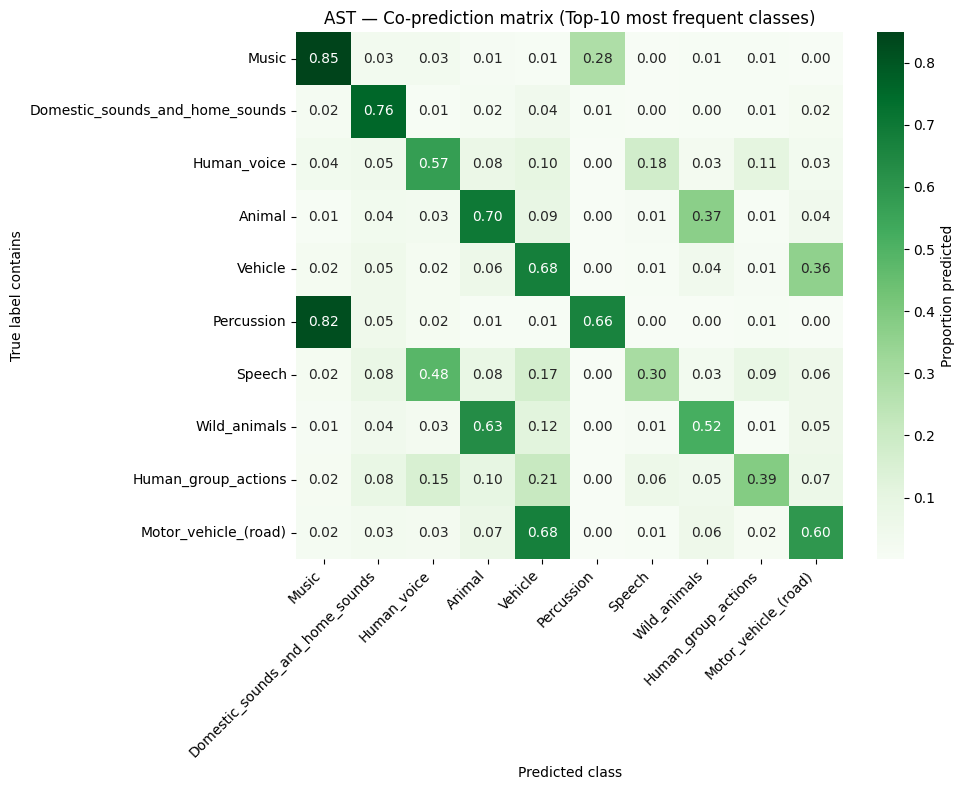

In [ ]:
support_counts = yt.sum(axis=0)
top10_idx      = np.argsort(support_counts)[::-1][:10]
top10_classes  = [top_labels[i] for i in top10_idx]

y_pred_bin = (pt >= best_th).astype(int)
co_err = np.zeros((10, 10), dtype=float)
for a, i in enumerate(top10_idx):
    mask = yt[:, i] == 1
    for b, j in enumerate(top10_idx):
        co_err[a, b] = y_pred_bin[mask, j].sum() / max(mask.sum(), 1)

plt.figure(figsize=(10, 8))
sns.heatmap(co_err, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=top10_classes, yticklabels=top10_classes,
            cbar_kws={"label": "Proportion predicted"})
plt.title("AST — Co-prediction matrix (Top-10 most frequent classes)")
plt.xlabel("Predicted class"); plt.ylabel("True label contains")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## **AST Summary Table**

Compact summary of the AST's performance for the final comparison table.

In [ ]:
ast_summary = pd.DataFrame([{
    "Model":     "AST (fine-tuned)",
    "Params":    f"{n_params/1e6:.1f} M",
    "Threshold": round(best_th, 2),
    "Micro-F1":  round(test_m["micro_f1"], 4),
    "Macro-F1":  round(test_m["macro_f1"], 4),
    "mAP":       round(test_m["mAP"], 4),
}])
ast_summary

,Model,Params,Threshold,Micro-F1,Macro-F1,mAP
0,AST (fine-tuned),86.3 M,0.25,0.6526,0.5985,0.6577


## **Discussion of Results**

### Training dynamics

The training converged through three distinct phases. During the warmup (epochs 1-2), the learning rate ramped from 0 to 3e-5, reaching a val mAP of 0.68 by the end of epoch 2. This confirms the benefit of AudioSet pretraining: the model was already in a competitive region of the parameter space before fine-tuning began. In the second phase (epochs 3-10), the model refined its predictions steadily, reaching its best checkpoint at epoch 10 with val mAP = 0.7019. In the third phase (epochs 11-12), train loss continued to decrease while val loss began to rise, confirming the onset of overfitting. Early stopping correctly halted training at epoch 13 after 5 consecutive epochs without improvement above the `MIN_DELTA` threshold.

### Test performance

| Metric | CNN | AST | Absolute gain | Relative gain |
|---|---|---|---|---|
| mAP | 0.4703 | **0.6577** | +0.187 | +40% |
| Micro-F1 | 0.5164 | **0.6526** | +0.136 | +26% |
| Macro-F1 | 0.4335 | **0.5985** | +0.165 | +38% |

The AST outperforms the CNN by a wide margin across all three metrics. The largest relative gain is in macro-F1 (+38%), the metric most sensitive to minority-class performance. This confirms that AudioSet pretraining is particularly effective for classes with limited data in FSD50K, where a CNN trained from scratch lacks sufficient signal to generalize.

### Per-class insights

**Top classes.** The AST excels on sounds with distinctive spectro-temporal signatures: Thunder (0.96), Cat (0.96), Zipper (0.95), Music (0.94), Applause (0.92), Writing (0.90). Notably, Zipper and Writing reach above 0.90 AP despite having only ~100 training samples, demonstrating that AudioSet pretraining compensates effectively for limited support when the acoustic signature is specific.

**Bottom classes.** The hardest categories remain Tap (0.10), Thump_and_thud (0.14), Wood (0.16) and Wind (0.23). These classes represent either acoustically ambiguous short transients or semantically broad categories that cover many heterogeneous realizations. Their difficulty is inherent to the task and not addressed by architectural improvements alone.

**Classes with large gains over the CNN.** Squeak (+0.22 AP), Organ (+0.19), Chink_and_clink (+0.16), Clapping (+0.13), and Bus (+0.12) show the largest improvements. These are classes where the CNN scored below 0.25 AP and where the AST's pretraining provides enough prior knowledge to reach usable performance.

### Confusion analysis: re-examining the hierarchy hypothesis

The project's initial hypothesis was that AST's global attention would reduce the CNN's tendency to collapse specific child labels into their generic parents (Percussion → Music, Motor_vehicle → Vehicle, Wild_animals → Animal, Speech → Human_voice). The co-prediction matrix, however, reveals a more nuanced picture:

| Hierarchical confusion | CNN | AST |
|---|---|---|
| Percussion → Music | 0.70 | 0.82 |
| Motor_vehicle → Vehicle | 0.53 | 0.68 |
| Wild_animals → Animal | 0.48 | 0.63 |
| Speech → Human_voice | 0.45 | 0.48 |

At first glance these values suggest the AST **worsens** hierarchical confusion. However, this reading is misleading once the diagonal recall is taken into account:

| Class | CNN recall | AST recall | Δ |
|---|---|---|---|
| Music | 0.73 | 0.85 | +0.12 |
| Motor_vehicle | 0.40 | 0.60 | +0.20 |
| Animal | 0.52 | 0.70 | +0.18 |
| Vehicle | 0.54 | 0.68 | +0.14 |
| Percussion | 0.56 | 0.66 | +0.10 |

The AST's recall is higher across every class in the top-10. When the ground truth contains both "Percussion" and "Music", the AST correctly identifies both simultaneously, which is the correct behavior under the hierarchical annotation of FSD50K. The CNN tended to prioritize one level over the other; the AST gets both.

**Revised interpretation:** the AST does not resolve hierarchical ambiguity by separating parent from child, but rather by improving the recall of both levels simultaneously. The net effect on global metrics is positive because FSD50K's ground truth itself is hierarchical. This is a more honest and more technically accurate reading than the original hypothesis suggested.

### Takeaway

The AST delivers a substantial improvement over the CNN across all aggregate metrics (+19 mAP, +14 micro-F1, +17 macro-F1 in absolute terms), driven by two complementary factors: the AudioSet pretraining (which provides strong initial representations for environmental sounds) and the global attention mechanism (which integrates context across the full 10-second clip). The remaining limitations — transient and semantically broad categories such as Tap, Wood or Wind — are likely not solvable by architectural changes alone and would benefit from approaches that incorporate semantic context beyond audio, such as audio-text joint models. The robustness of these results under noise is evaluated in notebook `06_robustness`.